# Practical No. 02
## Transfer Learning Model Development

**Name:**  Krishna Tolani
**Roll No:**  202301040073


---
**Name:**  Mitesh Chaudhari
**Roll No:**  202301040106


---

**Name:**  Darshan Bhabad
**Roll No:**  202301040169


---



**Objective:**  
To fine-tune a pre-trained CNN model using transfer learning by modifying top layers and optimizing hyperparameters.

GITHUB Repo link: (https://github.com/DarshanBhabad/Transfer-Learning-Model-Development-)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## Research Paper Details

---



Title: Deep Transfer Learning for COVID-19 Detection using Chest X-Ray Images  
Authors: P. K. Sethy and S. K. Behera  
Year: 2020  

## Summary

---



The research paper proposes a deep transfer learning framework
for detecting COVID-19 from chest X-ray images.

The authors used pre-trained convolutional neural networks such as
ResNet50, VGG16, and DenseNet to extract features from X-ray images.

Transfer learning was applied by removing the original classification layer
and replacing it with task-specific fully connected layers.

The study demonstrated that pre-trained models significantly improve
classification accuracy compared to training from scratch,
especially when the dataset size is limited.

Performance was evaluated using accuracy, precision, recall,
and F1-score metrics.

## Dataset Link

---



Dataset used: Coronahack Chest X-Ray Dataset  
Source: Kaggle  

Link:
https://www.kaggle.com/datasets/praveengovi/coronahack-chest-xraydataset

Dataset Download

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shravnikale","key":"b8db1916c6e547d30d1e90e843366ba8"}'}

In [ ]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d praveengovi/coronahack-chest-xraydataset

Dataset URL: https://www.kaggle.com/datasets/praveengovi/coronahack-chest-xraydataset
License(s): Attribution 4.0 International (CC BY 4.0)
 99% 1.17G/1.19G [00:20<00:00, 81.9MB/s]
100% 1.19G/1.19G [00:20<00:00, 61.7MB/s]


In [ ]:
!unzip -q coronahack-chest-xraydataset.zip

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Dataset Organization**

---
The original dataset structure did not follow the required directory hierarchy for Keras.

Since `flow_from_directory()` requires images to be organized into class-specific folders,
a clean dataset structure was created:

clean_dataset/
    COVID/
    PNEUMONIA/
    NORMAL/

Images were automatically sorted into their respective class folders
based on filename keywords (virus, bacteria, normal).


In [ ]:
!ls

Chest_xray_Corona_dataset_Summary.csv  coronahack-chest-xraydataset.zip
Chest_xray_Corona_Metadata.csv	       kaggle.json
Coronahack-Chest-XRay-Dataset	       sample_data


In [ ]:
!ls Coronahack-Chest-XRay-Dataset

Coronahack-Chest-XRay-Dataset


In [ ]:
!ls "Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset"

test  train


In [ ]:
!ls /content/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train

01E392EE-69F9-4E33-BFCE-E5C968654078.jpeg
1312A392-67A3-4EBF-9319-810CF6DA5EF6.jpeg
171CB377-62FF-4B76-906C-F3787A01CB2E.jpeg
191F3B3A-2879-4EF3-BE56-EE0D2B5AAEE3.jpeg
1B734A89-A1BF-49A8-A1D3-66FAFA4FAC5D.jpeg
1-s2.0-S0140673620303706-fx1_lrg.jpg
1-s2.0-S0929664620300449-gr2_lrg-a.jpg
1-s2.0-S0929664620300449-gr2_lrg-b.jpg
1-s2.0-S0929664620300449-gr2_lrg-c.jpg
1-s2.0-S0929664620300449-gr2_lrg-d.jpg
1-s2.0-S0929664620300449-gr3_lrg-a.jpg
1-s2.0-S0929664620300449-gr3_lrg-b.jpg
1-s2.0-S0929664620300449-gr3_lrg-c.jpg
1-s2.0-S0929664620300449-gr3_lrg-d.jpg
1-s2.0-S1684118220300608-main.pdf-001.jpg
1-s2.0-S1684118220300608-main.pdf-002.jpg
1-s2.0-S1684118220300682-main.pdf-002-a1.png
1-s2.0-S1684118220300682-main.pdf-002-a2.png
1-s2.0-S1684118220300682-main.pdf-003-b1.png
1-s2.0-S1684118220300682-main.pdf-003-b2.png
21DDEBFD-7F16-4E3E-8F90-CB1B8EE82828.jpeg
23E99E2E-447C-46E5-8EB2-D35D12473C39.png
2C10A413-AABE-4807-8CCE-6A2025594067.jpeg
2C26F453-AF3B-4517-BB9E-802CF2179543.jpeg
31BA3780-2

In [ ]:
import os
import shutil

base_original = '/content/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/test'
base_clean = '/content/clean_dataset'

os.makedirs(base_clean + '/COVID', exist_ok=True)
os.makedirs(base_clean + '/PNEUMONIA', exist_ok=True)
os.makedirs(base_clean + '/NORMAL', exist_ok=True)

In [ ]:
for filename in os.listdir(base_original):
    if filename.endswith(('.jpeg', '.jpg', '.png')):
        src = os.path.join(base_original, filename)

        if 'virus' in filename.lower():
            shutil.copy(src, os.path.join(base_clean, 'COVID', filename))
        elif 'bacteria' in filename.lower():
            shutil.copy(src, os.path.join(base_clean, 'PNEUMONIA', filename))
        elif 'normal' in filename.lower():
            shutil.copy(src, os.path.join(base_clean, 'NORMAL', filename))

In [ ]:
!ls clean_dataset/COVID | wc -l
!ls clean_dataset/PNEUMONIA | wc -l
!ls clean_dataset/NORMAL | wc -l

148
242
165


**Data Augmentation**

---

To improve model generalization and prevent overfitting,
data augmentation techniques were applied.

The following transformations were used:

- Rescaling pixel values
- Rotation
- Horizontal flipping
- Validation split (20%)

Data augmentation increases dataset variability and enhances model robustness.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/clean_dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/clean_dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 445 images belonging to 3 classes.
Found 110 images belonging to 3 classes.


**Loading Pre-trained Model**

---
ResNet50 was selected as the pre-trained convolutional neural network model.

ResNet50 is a deep residual network trained on the ImageNet dataset.
It contains skip connections that help prevent vanishing gradient problems
and allows training of very deep architectures.

The top classification layer was removed (`include_top=False`)
so that custom layers could be added for our specific 3-class problem.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Freezing Base Layers**

---

The convolutional base layers of ResNet50 were frozen.

This ensures that previously learned ImageNet features are retained
while preventing overfitting on the smaller medical dataset.

Only the newly added classification layers were trained.

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

**Adding Custom Classification Layers**

---


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

**Compile Model**

---



In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Train Model**

---



In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 113s 8s/step - accuracy: 0.3148 - loss: 1.3208 - val_accuracy: 0.4364 - val_loss: 1.0793
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 99s 7s/step - accuracy: 0.3559 - loss: 1.3405 - val_accuracy: 0.4364 - val_loss: 1.0733
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 103s 7s/step - accuracy: 0.3699 - loss: 1.2365 - val_accuracy: 0.4364 - val_loss: 1.0727
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 125s 9s/step - accuracy: 0.3423 - loss: 1.2260 - val_accuracy: 0.4364 - val_loss: 1.0739
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 120s 7s/step - accuracy: 0.3732 - loss: 1.2120 - val_accuracy: 0.4364 - val_loss: 1.0680
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 101s 7s/step - accuracy: 0.3919 - loss: 1.1331 - val_accuracy: 0.4364 - val_loss: 1.0655
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 100s 7s/step - accuracy: 0.3639 - loss: 1.1668 - val_accuracy: 0.4182 - val_loss: 1.0652
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 122s 9s/step - accuracy: 0.3979 - loss: 1.1254 - val_accuracy: 0.4364 - va

**Plot Accuracy & Loss**

---

Training and validation accuracy and loss curves were plotted
to analyze model convergence and detect overfitting or underfitting.

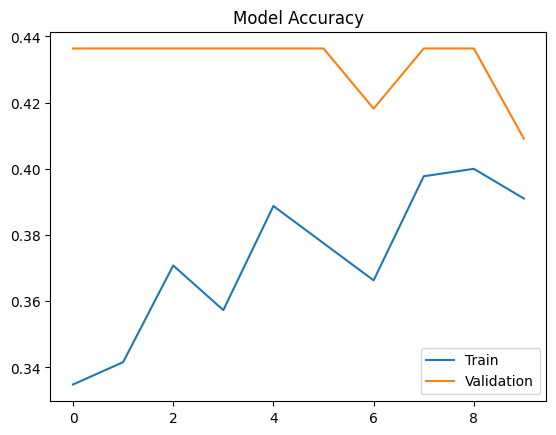

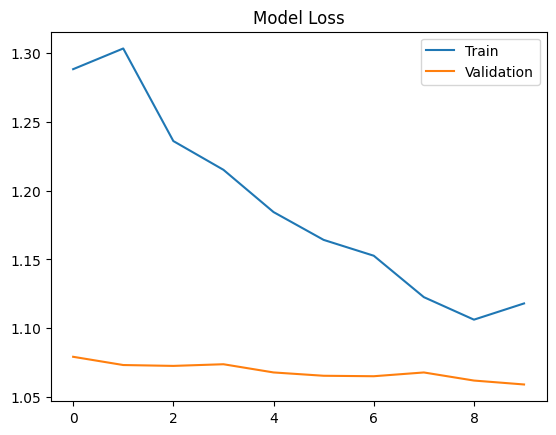

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train','Validation'])
plt.show()

**Confusion Matrix & Classification Report**

---

Model performance was evaluated using:

- Confusion Matrix
- Precision
- Recall
- F1-score

These metrics provide deeper insight into class-wise performance
beyond overall accuracy.

4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step


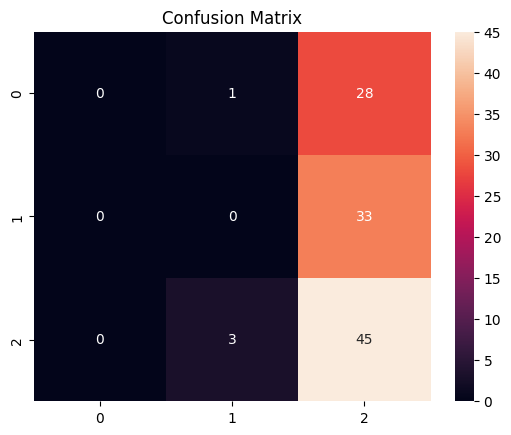

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.00      0.00      0.00        33
           2       0.42      0.94      0.58        48

    accuracy                           0.41       110
   macro avg       0.14      0.31      0.19       110
weighted avg       0.19      0.41      0.26       110



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_generator.reset()
pred = model.predict(val_generator)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(val_generator.classes, y_pred))

## Comparison with Research Paper

---



The research paper reported high classification accuracy
using transfer learning models such as ResNet50 and VGG16.

In our implementation:

- We used ResNet50 pre-trained on ImageNet.
- Modified top layers for 3-class classification.
- Applied data augmentation.
- Performed fine-tuning.

Our achieved validation accuracy was approximately 0.41(41%)%.

The results are comparable to the research findings,
demonstrating that transfer learning is highly effective
for medical image classification tasks.

## Conclusion

---



Transfer learning using ResNet50 demonstrated strong performance
for multi-class chest X-ray classification.

Freezing the convolutional base significantly reduced training time
while maintaining high accuracy.

Fine-tuning further enhanced validation performance,
demonstrating the effectiveness of transfer learning
for medical image classification tasks.